# 01 Data Cleaning and Dataset Preparation

This notebook prepares the raw Waterloo/Kitchener traffic collision dataset for the injury severity classification project.

Project question:
Given that a collision occurred, what factors increase the probability that the collision results in injury rather than non-injury?

### Step 1: Import libraries and load raw data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a consistent figure size and turn on grid for all plots
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

### Step 2: Inspect the raw dataset

In [3]:
# Load the raw CSV file
df = pd.read_csv('../Data/Raw/Traffic_Collisions.csv')

print('Raw shape:', df.shape)
df.head()
# Quick overview: column names, dtypes, and non-null counts
df.info()

Raw shape: (8928, 42)
<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   OBJECTID                     8928 non-null   int64  
 1   ACCIDENTNUM                  8928 non-null   str    
 2   ACCIDENTDATE                 8928 non-null   str    
 3   ACCIDENT_YEAR                8928 non-null   int64  
 4   ACCIDENT_MONTH               8928 non-null   int64  
 5   ACCIDENT_DAY                 8928 non-null   int64  
 6   ACCIDENT_HOUR                8928 non-null   int64  
 7   ACCIDENT_MINUTE              8928 non-null   int64  
 8   ACCIDENT_SECOND              8928 non-null   int64  
 9   ACCIDENT_WEEKDAY             8928 non-null   str    
 10  XCOORD                       8928 non-null   float64
 11  YCOORD                       8928 non-null   float64
 12  LONGITUDE                    8928 non-null   float64
 13  LATITUD

### Step 3: Inspect the outcome related columns before cleaning

We first inspect `CLASSIFICATIONOFACCIDENT` to confirm the exact labels that will be used to create the binary injury target.

We also inspect `COLLISIONTYPE` because it may directly encode severity and therefore cause data leakage if used as a feature.

In [4]:
print('CLASSIFICATIONOFACCIDENT value counts:')
print(df['CLASSIFICATIONOFACCIDENT'].value_counts(dropna=False))

print('\nCOLLISIONTYPE value counts:')
print(df['COLLISIONTYPE'].value_counts(dropna=False))

CLASSIFICATIONOFACCIDENT value counts:
CLASSIFICATIONOFACCIDENT
P.D. only           6568
Non-fatal injury    1202
Non-reportable      1140
Fatal injury           9
unknown                7
Other                  2
Name: count, dtype: int64

COLLISIONTYPE value counts:
COLLISIONTYPE
2    7717
1    1202
0       9
Name: count, dtype: int64


### Step 4: Drop irrelevant, admin, empty, and leakage columns

We remove:
- identifiers and metadata
- detailed coordinates that aren't used
- fully empty columns
- `COLLISIONTYPE`, since it leaks severity information and would act like a copy of the target

In [ ]:
drop_cols = [
    "OBJECTID", #Identifier so irrelevant
    "ACCIDENTNUM",
    "ACCIDENTDATE",
    "ACCIDENT_MINUTE", #small time unit nto useful for prediction
    "ACCIDENT_SECOND",
    "LATITUDE", # Coordinates aren't used for this model
    "LONGITUDE",
    "XCOORD",
    "YCOORD",
    "x", 
    "y",
    "XMLIMPORTNOTES", #Text notes not useful
    "LASTEDITEDDATE", #log date not useful for prediction
    "CREATE_DATE",
    "CREATE_BY",
    "ENVIRONMENTCONDITION2",
    "SELFREPORTED", #irrelevant
    "COLLISIONTYPE", # Leakage must drop
    "INITIALDIRECTIONOFTRAVELONE",
    "INITIALDIRECTIONOFTRAVELTWO", #irrelevant for predection
    "INTTRAFFICCONTROL" #redundant w Trafficcontrol col
]
# Only drop columns that actually exist
existing_drop = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=existing_drop)

print('Shape after dropping irrelevant columns:', df.shape)
print('Dropped:', existing_drop)

Shape after dropping irrelevant columns: (8928, 21)
Dropped: ['OBJECTID', 'ACCIDENTNUM', 'ACCIDENTDATE', 'ACCIDENT_MINUTE', 'ACCIDENT_SECOND', 'LATITUDE', 'LONGITUDE', 'XCOORD', 'YCOORD', 'x', 'y', 'XMLIMPORTNOTES', 'LASTEDITEDDATE', 'CREATE_DATE', 'CREATE_BY', 'ENVIRONMENTCONDITION2', 'SELFREPORTED', 'COLLISIONTYPE', 'INITIALDIRECTIONOFTRAVELONE', 'INITIALDIRECTIONOFTRAVELTWO', 'INTTRAFFICCONTROL']


### Step 5: Create binary injury target

We create a binary target called `injury` from `CLASSIFICATIONOFACCIDENT`.

Mapping:
- `Non-fatal injury` and `Fatal injury` will be mapped to 1
- `P.D. only` and `Non-reportable` mapped to 0

Rows with `unknown` or `Other` will be removed because they don't map cleanly to the binary target.

In [6]:
injury_map = {
    "Non-fatal injury": 1,
    "Fatal injury":     1,
    "P.D. only":        0,
    "Non-reportable":   0,
    # There are 7 rows with the values "unknown" and 2 rows with the value "Other" which won't be mapped so it will become NaN then dropped
}

df["injury"] = df["CLASSIFICATIONOFACCIDENT"].map(injury_map)

# Check how many rows are being dropped
print('Rows with unmapped labels:', df['injury'].isna().sum())
print(df.loc[df['injury'].isna(), 'CLASSIFICATIONOFACCIDENT'].value_counts(dropna=False))

# Remove the unmapped rows
df = df[df['injury'].notna()].copy()
df['injury'] = df['injury'].astype(int)

print('\nShape after removing unmapped rows:', df.shape)
print('\nInjury class counts:')
print(df['injury'].value_counts())
print('\nInjury class proportions:')
print(df['injury'].value_counts(normalize=True).round(3))

# Drop the source column since it can't appear as a feature
df = df.drop(columns=['CLASSIFICATIONOFACCIDENT'])
print('\nDropped CLASSIFICATIONOFACCIDENT.')

Rows with unmapped labels: 9
CLASSIFICATIONOFACCIDENT
unknown    7
Other      2
Name: count, dtype: int64

Shape after removing unmapped rows: (8919, 22)

Injury class counts:
injury
0    7708
1    1211
Name: count, dtype: int64

Injury class proportions:
injury
0    0.864
1    0.136
Name: proportion, dtype: float64

Dropped CLASSIFICATIONOFACCIDENT.


### Step 6: Handle missing values and verify data quality

We check for missing values across all columns and handle them appropriately.

- Categorical missing values are filled with `Unknown`
- Numeric columns are inspected but not imputed yet
- Duplicate rows are checked and removed to ensure data integrity

In [7]:
# Check missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

# Only show columns that actually have missing values
print(missing_summary[missing_summary['missing_count'] > 0])

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Fill missing categorical values with 'Unknown'
for col in cat_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna('Unknown')

print('Missing values remaining in categorical columns:', df[cat_cols].isna().sum().sum())

# Check numeric columns
print('\nNumeric column summary:')
print(df[num_cols].describe())

# Count duplicates before removing
print('Duplicate rows before removal:', df.duplicated().sum())

# Remove duplicates and keep the first occurrence
df = df.drop_duplicates(keep='first').copy()

print('Duplicate rows after removal:', df.duplicated().sum())
print('Shape after duplicate removal:', df.shape)

                missing_count  missing_pct
LIGHT                       1     0.011212
LIGHTFORREPORT              1     0.011212
Missing values remaining in categorical columns: 0

Numeric column summary:
       ACCIDENT_YEAR  ACCIDENT_MONTH  ACCIDENT_DAY  ACCIDENT_HOUR  \
count    8919.000000     8919.000000   8919.000000    8919.000000   
mean     2018.056509        6.286691     15.458347      13.197219   
std         2.104511        3.616760      8.798575       5.217839   
min      2015.000000        1.000000      1.000000       0.000000   
25%      2016.000000        3.000000      8.000000       9.000000   
50%      2018.000000        6.000000     15.000000      14.000000   
75%      2020.000000       10.000000     23.000000      17.000000   
max      2022.000000       12.000000     31.000000      23.000000   

        THRULANENO  NORTHBOUNDDISOBEYCOUNT  SOUTHBOUNDDISOBEYCOUNT  \
count  8919.000000             8919.000000             8919.000000   
mean      0.049557               

/tmp/ipykernel_10068/942528319.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


### Step 7: Decide between LIGHT and LIGHTFORREPORT

These two columns may carry the same information. We use a cross-tabulation to check how often they agree. If they're nearly identical, we can drop one to reduce redundancy.

In [8]:
# Compare the two lighting columns to see how they relate
if 'LIGHT' in df.columns and 'LIGHTFORREPORT' in df.columns:
    light_ct = pd.crosstab(df['LIGHT'], df['LIGHTFORREPORT'], dropna=False)
    print(light_ct)

    # Calculate the row-wise agreement rate (Note: this was aided by AI)
    agreement = (df['LIGHT'].astype(str) == df['LIGHTFORREPORT'].astype(str)).mean()
    print('\nExact row-wise agreement:', round(agreement, 4))
else:
    print('One or both LIGHT columns not found.')

# LIGHT and LIGHTFORREPORT are highly correlated so we keep LIGHT and drop LIGHTFORREPORT
# Since LIGHT uses regular easy to understand labels ('Daylight' etc) which are easier to interpret in EDA
if 'LIGHTFORREPORT' in df.columns:
    df = df.drop(columns=['LIGHTFORREPORT'])
    print('Dropped LIGHTFORREPORT, kept LIGHT.')

LIGHTFORREPORT        00 - Unknown  01 - Daylight  02 - Daylight, artificial  \
LIGHT                                                                          
Dark                             0              0                          0   
Dark, artificial                 0              0                          0   
Dawn                             0              0                          0   
Dawn, artificial                 0              0                          0   
Daylight                         0           6445                          0   
Daylight, artificial             0              0                         95   
Dusk                             0              0                          0   
Dusk, artificial                 0              0                          0   
Other                            0              0                          0   
Unknown                          3              0                          0   

LIGHTFORREPORT        03 - Dawn  04 - D

### Step 8: Inspect remaining categorical columns

Before EDA, we'll check the unique value counts and the most common category for each categorical feature. This should help us identify high cardinality columns.

In [9]:
# Refresh the list of categorical columns after dropping columns above
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print(f'\n--- {col} ---')
    print('Unique values:', df[col].nunique(dropna=False))
    print(df[col].value_counts(dropna=False).head(10))


--- ACCIDENT_WEEKDAY ---
Unique values: 7
ACCIDENT_WEEKDAY
Friday       1494
Thursday     1323
Tuesday      1308
Wednesday    1295
Monday       1280
Saturday     1202
Sunday        990
Name: count, dtype: int64

--- ACCIDENTLOCATION ---
Unique values: 8
ACCIDENTLOCATION
Non intersection         3202
At/near private drive    2447
At intersection          1684
Intersection related     1377
Other                     144
At railway crossing        20
Overpass or bridge         11
Underpass or tunnel         7
Name: count, dtype: int64

--- IMPACTLOCATION ---
Unique values: 13
IMPACTLOCATION
Thru lane                      5211
Within intersection            1677
Right shoulder                  595
Not on roadway - right side     497
Off highway                     346
Not on roadway - left side      193
Left turn lane                  137
Right turn lane                  96
Other                            55
Left shoulder                    52
Name: count, dtype: int64

--- INITIALIMPACTT

/tmp/ipykernel_10068/1977535115.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


### Step 9: Final Check then Export cleaned dataset
We export the cleaned dataset so we can use it for EDA later.

In [10]:
print('Final cleaned shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nAny remaining missing values?')
remaining = df.isna().sum()
print(remaining[remaining > 0])
df.head()
df.to_csv("../Data/Cleaned/collisions_cleaned.csv", index=False)
print("Cleaned dataset saved.")

Final cleaned shape: (8892, 20)

Data types:
ACCIDENT_YEAR              int64
ACCIDENT_MONTH             int64
ACCIDENT_DAY               int64
ACCIDENT_HOUR              int64
ACCIDENT_WEEKDAY             str
ACCIDENTLOCATION             str
IMPACTLOCATION               str
INITIALIMPACTTYPE            str
LIGHT                        str
ROADJURISDICTION             str
TRAFFICCONTROL               str
TRAFFICCONTROLCONDITION      str
THRULANENO                 int64
NORTHBOUNDDISOBEYCOUNT     int64
SOUTHBOUNDDISOBEYCOUNT     int64
PEDESTRIANINVOLVED          bool
CYCLISTINVOLVED             bool
MOTORCYCLISTINVOLVED        bool
ENVIRONMENTCONDITION1        str
injury                     int64
dtype: object

Any remaining missing values?
Series([], dtype: int64)
Cleaned dataset saved.


# Exploratory Data Analysis (EDA)

### EDA 1: Injury class distribution

We first need to figure out how balanced the target variable is. If its imbalanced then accuracy alone wouldn't evaluate it well (since a model that would always predict the majority class would still have a high accuracy score.)

Counts:
injury
0    7681
1    1211
Name: count, dtype: int64

Proportions:
injury
0    0.864
1    0.136
Name: proportion, dtype: float64


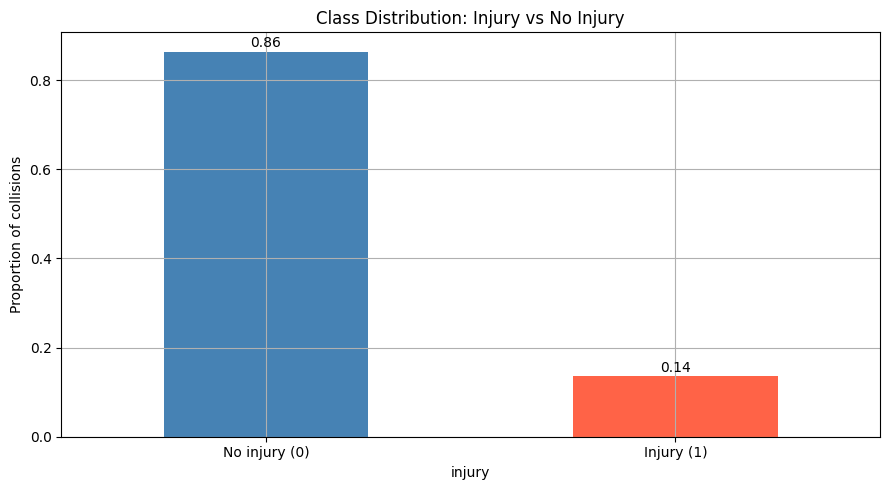

In [11]:
#Note: AI assitance in plotting to help with the look. This is true for most of the plots
injury_counts = df['injury'].value_counts().sort_index()
injury_props  = df['injury'].value_counts(normalize=True).sort_index()

print('Counts:')
print(injury_counts)
print('\nProportions:')
print(injury_props.round(3))

plt.figure()
ax = injury_props.plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['No injury (0)', 'Injury (1)'], rotation=0)
plt.ylabel('Proportion of collisions')
plt.title('Class Distribution: Injury vs No Injury')

# Add proportion labels on top of each bar
for i, v in enumerate(injury_props):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

The target is imbalanced. As you can see above, non-injury collisions make up the vast majority of the data. This is something we need to consider when modeling since the other metrics like precision, recall, and F1 will matter more than accuracy.

### EDA 2: Injury rate by hour of day

We group by `ACCIDENT_HOUR` and compute the mean of `injury` within each hour. The mean of a binary column gives the injury rate (proportion of collisions that resulted in injury).

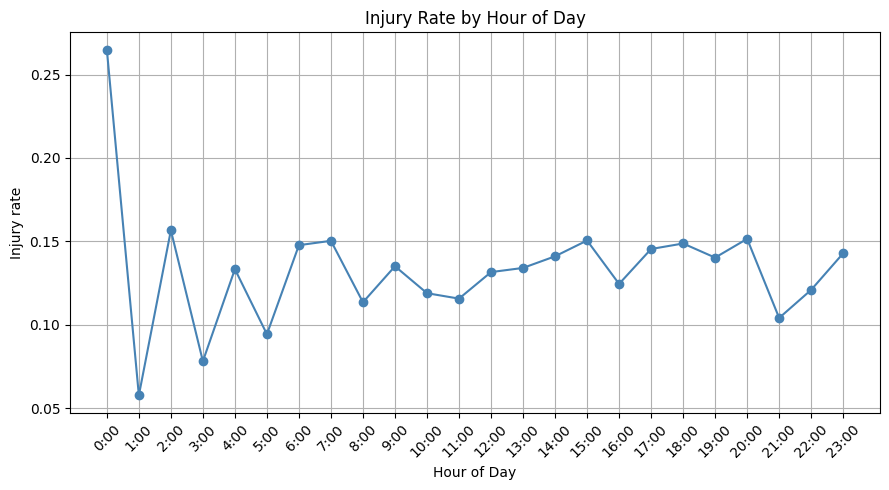

Hourly injury rates:
ACCIDENT_HOUR
0     0.265
1     0.058
2     0.157
3     0.078
4     0.133
5     0.094
6     0.148
7     0.150
8     0.113
9     0.135
10    0.119
11    0.116
12    0.132
13    0.134
14    0.141
15    0.151
16    0.124
17    0.145
18    0.149
19    0.140
20    0.152
21    0.104
22    0.121
23    0.143
Name: injury, dtype: float64


In [12]:
# Compute injury rate for each hour of the day (0 through 23)
hourly = df.groupby('ACCIDENT_HOUR')['injury'].mean().reindex(range(24))

plt.figure()
hourly.plot(kind='line', marker='o', color='steelblue')
plt.xticks(range(24), [f'{h}:00' for h in range(24)], rotation=45)
plt.xlabel('Hour of Day')
plt.ylabel('Injury rate')
plt.title('Injury Rate by Hour of Day')
plt.tight_layout()
plt.show()

print('Hourly injury rates:')
print(hourly.round(3))

Injury rates fluctuate throughout the day but generally remain between 10–15%. There is a pretty noticeable spike around midnight, likely due to low visibility or riskier driving conditions, while daytime hours show more stable injury rates. However, time of day doesn't appear to be a dominant factor compared to other factors.

### EDA 3: Injury rate by lighting condition

We group by `LIGHT` and sort by injury rate to see which lighting conditions are associated with higher injury rates.

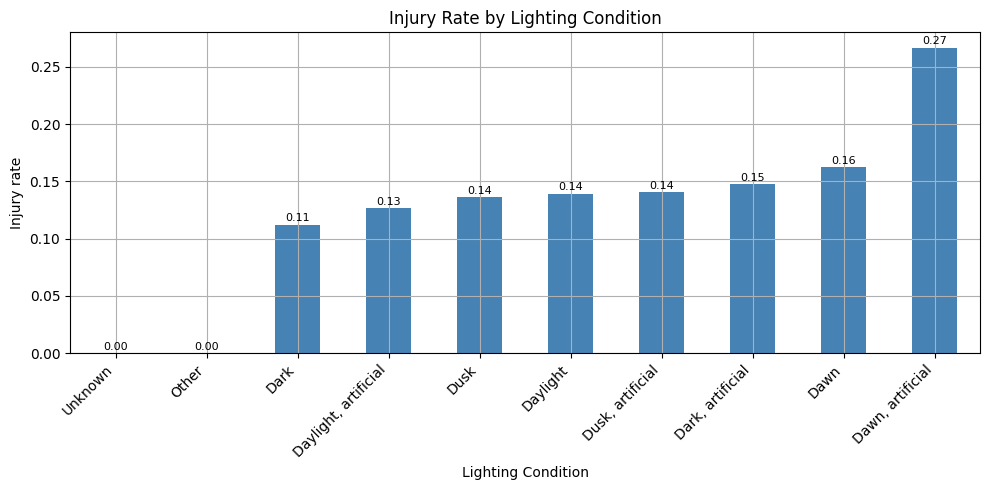

                      count  injury_rate
LIGHT                                   
Dawn, artificial         15     0.266667
Dawn                    117     0.162393
Dark, artificial        711     0.147679
Dusk, artificial         57     0.140351
Daylight               6445     0.139178
Dusk                    235     0.136170
Daylight, artificial     95     0.126316
Dark                   1194     0.112228
Other                    19     0.000000
Unknown                   4     0.000000


In [13]:
# Compute injury rate and observation count for each lighting condition
light_rates  = df.groupby('LIGHT')['injury'].mean().sort_values()
light_counts = df['LIGHT'].value_counts(dropna=False)

plt.figure(figsize=(10, 5))
ax = light_rates.plot(kind='bar', color='steelblue')
plt.xlabel('Lighting Condition')
plt.ylabel('Injury rate')
plt.title('Injury Rate by Lighting Condition')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(light_rates):
    ax.text(i, v + 0.003, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Show both the count and injury rate for each category
print(pd.DataFrame({
    'count':       light_counts,
    'injury_rate': df.groupby('LIGHT')['injury'].mean()
}).sort_values('injury_rate', ascending=False))

Injury rates tend to increase in lower visibility conditions, with “Dawn, artificial” showing the highest rate. Daylight conditions have lower injury rates, while darker conditions such as dusk and night show moderate increases. This suggests that reduced visibility is associated with more severe collision outcomes.

### EDA 4: Injury rate by environment condition

We look at `ENVIRONMENTCONDITION1` to see whether weather/road surface conditions affect injury rates.

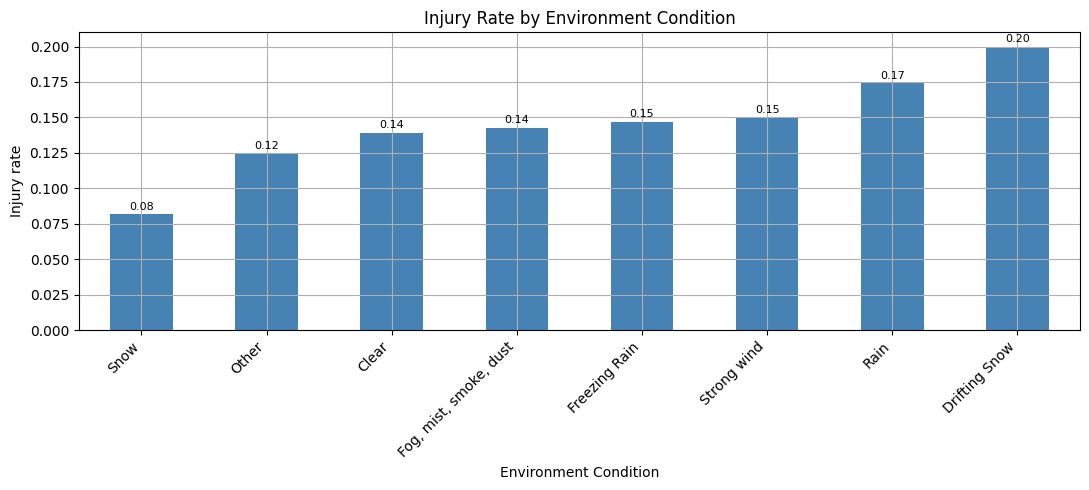

                        count  injury_rate
ENVIRONMENTCONDITION1                     
Drifting Snow              30     0.200000
Rain                      661     0.173979
Strong wind                20     0.150000
Freezing Rain              68     0.147059
Fog, mist, smoke, dust     42     0.142857
Clear                    7130     0.139271
Other                      24     0.125000
Snow                      917     0.081788


In [14]:
env_rates  = df.groupby('ENVIRONMENTCONDITION1')['injury'].mean().sort_values()
env_counts = df['ENVIRONMENTCONDITION1'].value_counts(dropna=False)

plt.figure(figsize=(11, 5))
ax = env_rates.plot(kind='bar', color='steelblue')
plt.xlabel('Environment Condition')
plt.ylabel('Injury rate')
plt.title('Injury Rate by Environment Condition')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(env_rates):
    ax.text(i, v + 0.003, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'count':       env_counts,
    'injury_rate': df.groupby('ENVIRONMENTCONDITION1')['injury'].mean()
}).sort_values('injury_rate', ascending=False))

Injury rates increase as weather conditions become more severe or just worse. Clear and snow conditions have relatively lower injury rates, while rain and especially drifting snow show noticeably higher rates. This is pretty consistent with reduced visibility and poor road conditions leading to more severe collision outcomes

### EDA 5: Injury rate for vulnerable road users

We check the injury rate separately for collisions involving pedestrians, cyclists, and motorcyclists. Since these columns contain the string `'True'`/`'False'` rather than actual booleans, we convert them before filtering.


PEDESTRIANINVOLVED:
PEDESTRIANINVOLVED
False    8655
True      237
Name: count, dtype: int64

CYCLISTINVOLVED:
CYCLISTINVOLVED
False    8731
True      161
Name: count, dtype: int64

MOTORCYCLISTINVOLVED:
MOTORCYCLISTINVOLVED
False    8828
True       64
Name: count, dtype: int64


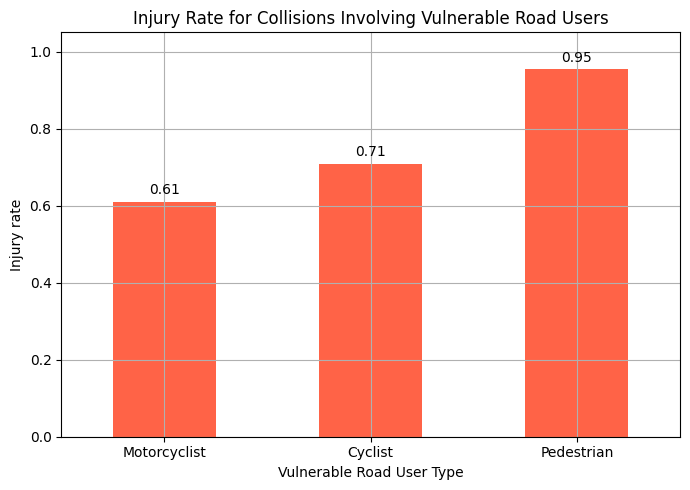

              count  injury_rate
Pedestrian      237     0.953586
Cyclist         161     0.708075
Motorcyclist     64     0.609375


In [15]:
# Check the raw values in the vulnerable user columns
for col in ['PEDESTRIANINVOLVED', 'CYCLISTINVOLVED', 'MOTORCYCLISTINVOLVED']:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts(dropna=False))

# The columns store the string 'True'/'False', so we convert to lowercase before comparing
def is_involved(series):
    return series.astype(str).str.strip().str.lower() == 'true'

# Compute injury rate for each group and store in a Series
vru_labels = {
    'Pedestrian':   'PEDESTRIANINVOLVED',
    'Cyclist':      'CYCLISTINVOLVED',
    'Motorcyclist': 'MOTORCYCLISTINVOLVED'
}

vru_rates = {}
vru_counts = {}

for label, col in vru_labels.items():
    if col in df.columns:
        mask = is_involved(df[col])
        vru_rates[label]  = df.loc[mask, 'injury'].mean()
        vru_counts[label] = int(mask.sum())

vru_rates = pd.Series(vru_rates).sort_values()

plt.figure(figsize=(7, 5))
ax = vru_rates.plot(kind='bar', color='tomato')
plt.xlabel('Vulnerable Road User Type')
plt.ylabel('Injury rate')
plt.title('Injury Rate for Collisions Involving Vulnerable Road Users')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

for i, v in enumerate(vru_rates):
    ax.text(i, min(v + 0.02, 1.02), f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Summary table with counts
print(pd.DataFrame({
    'count':       pd.Series(vru_counts),
    'injury_rate': vru_rates
}).sort_values('injury_rate', ascending=False))

Collisions involving vulnerable road users have significantly higher injury rates compared to the overall dataset. Nearly all collisions involving pedestrians result in injury, while cyclists and motorcyclists also show significantly elevated injury probabilities. This indicates that vulnerable users are disproportionately affected in collisions and represent one of the strongest predictors of injury severity. Also, these groups in general are relatively rare in the dataset, but when they are involved, the likelihood of injury is much higher than average.
**Note: These categories also have relatively small sample sizes, particularly for motorcyclists, so while the trend is strong, the estimates may be more sensitive to variation.**

### EDA 6: Injury rate by traffic control

We group by `TRAFFICCONTROL` to check whether the type of traffic control at the collision location is associated with injury rate.

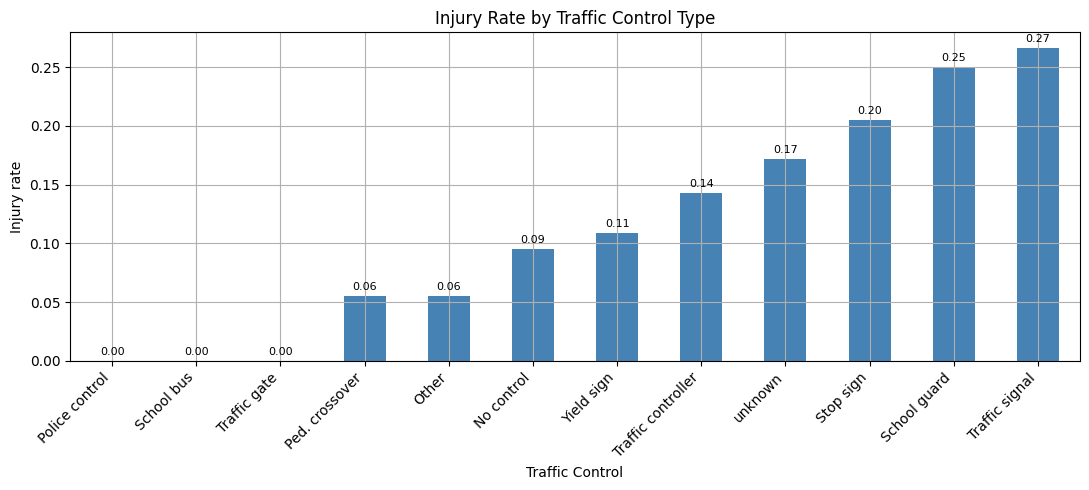

                    count  injury_rate
TRAFFICCONTROL                        
Traffic signal        830     0.266265
School guard            4     0.250000
Stop sign            1674     0.204898
unknown               524     0.171756
Traffic controller      7     0.142857
Yield sign            110     0.109091
No control           5701     0.094896
Other                  18     0.055556
Ped. crossover         18     0.055556
Police control          1     0.000000
School bus              3     0.000000
Traffic gate            2     0.000000


In [16]:
traffic_rates  = df.groupby('TRAFFICCONTROL')['injury'].mean().sort_values()
traffic_counts = df['TRAFFICCONTROL'].value_counts(dropna=False)

plt.figure(figsize=(11, 5))
ax = traffic_rates.plot(kind='bar', color='steelblue')
plt.xlabel('Traffic Control')
plt.ylabel('Injury rate')
plt.title('Injury Rate by Traffic Control Type')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(traffic_rates):
    ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'count':       traffic_counts,
    'injury_rate': df.groupby('TRAFFICCONTROL')['injury'].mean()
}).sort_values('injury_rate', ascending=False))

Injury rates vary quite a bit across traffic control types. Locations with traffic signals and school guards show some of the highest injury rates, while areas with no control or yield signs are noticeably lower. This suggests that intersections with more complex traffic flow may be associated with more severe collisions, rather than safer ones.

### EDA 7: Injury rate by accident location

We group by `ACCIDENTLOCATION` to check whether the type of road location (intersection, private drive, etc.) is associated with injury rate.

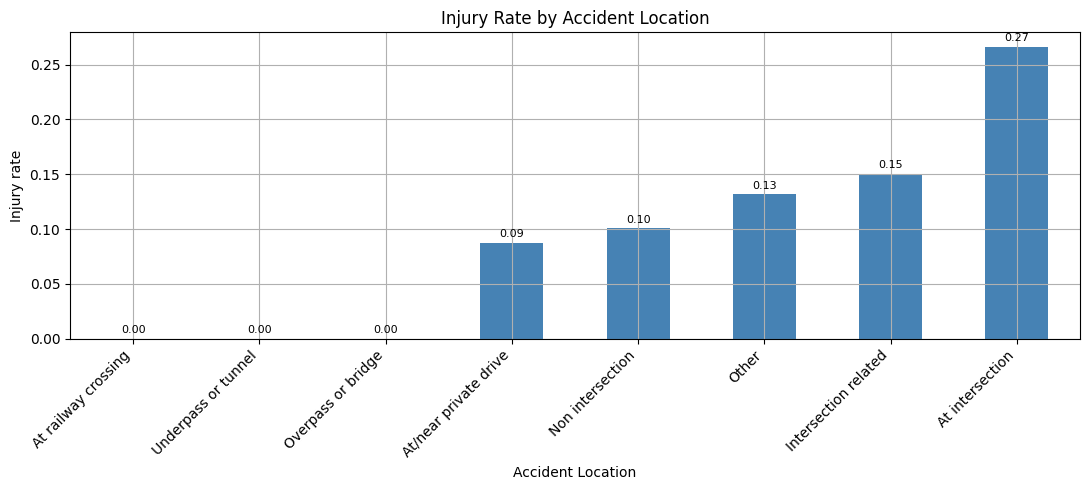

                       count  injury_rate
ACCIDENTLOCATION                         
At intersection         1684     0.266033
Intersection related    1377     0.150327
Other                    144     0.131944
Non intersection        3202     0.100874
At/near private drive   2447     0.087454
At railway crossing       20     0.000000
Overpass or bridge        11     0.000000
Underpass or tunnel        7     0.000000


In [17]:
acc_loc_rates  = df.groupby('ACCIDENTLOCATION')['injury'].mean().sort_values()
acc_loc_counts = df['ACCIDENTLOCATION'].value_counts(dropna=False)

plt.figure(figsize=(11, 5))
ax = acc_loc_rates.plot(kind='bar', color='steelblue')
plt.xlabel('Accident Location')
plt.ylabel('Injury rate')
plt.title('Injury Rate by Accident Location')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(acc_loc_rates):
    ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'count':       acc_loc_counts,
    'injury_rate': df.groupby('ACCIDENTLOCATION')['injury'].mean()
}).sort_values('injury_rate', ascending=False))

Accident location shows fairly clear differences in injury rate. Some location types such as highway or non-intersection locations show different patterns from intersection-related ones. This would suggest that the road type and type of traffic interaction matter for injury severity.

### Overall Analysis
The analysis shows that collisions involving pedestrians, cyclists, or motorcyclists are much more likely to result in injury, making vulnerable road users the strongest signal in the dataset. Weather and visibility also matter, as conditions like rain, drifting snow, and low light show higher injury rates. Road context is another important factor, with intersections and areas that have more complex traffic control showing higher severity compared to simpler locations. Time of day does show some variation, but the effect is smaller than the other factors. Overall, vulnerable user involvement, environment, and road structure stand out as the most important features to carry into the modeling stage.

The Clearest Pattern in the dataset Summary:
- **Vulnerable road-user involvement** is the strongest signal as pedestrian, cyclist, and motorcyclist collisions are far more likely to result in injury than the dataset average
- **Lighting and environment conditions** matter as lower visibility and harsher weather show consistently higher injury rates
- **Road context variables** (traffic control type, accident location) also show meaningful variation in injury rate
- **Time of day** shows some variation but is a weaker effect than the factors above

**NOTE: The relative importance of each feature will need to be validated through proper model training, feature selection, and evaluation which well be doing next. Also, I'm further emphasizing that some categories in the plots above have small observation counts (sub 30), which means their injury rates may not be good estimates.**